# Effect of COVID-19 Lockdown on Air Pollutant Levels in California (2019–2021)


In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

In [45]:
#load all 2019 air quality datasets
co_19  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/CO_2019.csv')
no2_19 = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/NO2_2019.csv')
o3_19  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/O3_2019.csv')
pm25_19= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/PM2.5_2019.csv')
pm10_19= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/PM10_2019.csv')

#load all 2020 air quality datasets
co_20  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/CO_2020.csv')
no2_20 = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/NO2_2020.csv')
o3_20  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/O3_2020.csv')
pm25_20= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/PM2.5_2020.csv')
pm10_20= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/PM10_2020.csv')

#load all 2021 air quality datasets
co_21  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/CO_2021.csv')
no2_21 = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/NO2_2021.csv')
o3_21  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/O3_2021.csv')
pm25_21= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/PM2.5_2021.csv')
pm10_21= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/PM10_2021.csv')

#load covid data
covid  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/covid19cases_deaths.csv')

---
## Step 1: Initial Exploration



In [ ]:
co_19.head()

,Date,Source,Site ID,POC,Daily Max 8-hour CO Concentration,UNITS,DAILY_AQI_VALUE,Site Name,DAILY_OBS_COUNT,PERCENT_COMPLETE,AQS_PARAMETER_CODE,AQS_PARAMETER_DESC,CBSA_CODE,CBSA_NAME,STATE_CODE,STATE,COUNTY_CODE,COUNTY,SITE_LATITUDE,SITE_LONGITUDE
0,01/01/2019,AQS,60010009,1,0.4,ppm,5,Oakland,18,75.0,42101,Carbon monoxide,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.743065,-122.169935
1,01/02/2019,AQS,60010009,1,0.6,ppm,7,Oakland,24,100.0,42101,Carbon monoxide,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.743065,-122.169935
2,01/03/2019,AQS,60010009,1,0.6,ppm,7,Oakland,24,100.0,42101,Carbon monoxide,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.743065,-122.169935
3,01/04/2019,AQS,60010009,1,0.7,ppm,8,Oakland,24,100.0,42101,Carbon monoxide,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.743065,-122.169935
4,01/05/2019,AQS,60010009,1,0.6,ppm,7,Oakland,24,100.0,42101,Carbon monoxide,41860,"San Francisco-Oakland-Hayward, CA",6,California,1,Alameda,37.743065,-122.169935


In [ ]:
co_19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22290 entries, 0 to 22289
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               22290 non-null  object 
 1   Source                             22290 non-null  object 
 2   Site ID                            22290 non-null  int64  
 3   POC                                22290 non-null  int64  
 4   Daily Max 8-hour CO Concentration  22290 non-null  float64
 5   UNITS                              22290 non-null  object 
 6   DAILY_AQI_VALUE                    22290 non-null  int64  
 7   Site Name                          22290 non-null  object 
 8   DAILY_OBS_COUNT                    22290 non-null  int64  
 9   PERCENT_COMPLETE                   22290 non-null  float64
 10  AQS_PARAMETER_CODE                 22290 non-null  int64  
 11  AQS_PARAMETER_DESC                 22290 non-null  obj

In [ ]:
#how many unique counties, sites, and days do we have?
print('Counties :', co_19['COUNTY'].nunique())
print('Sites    :', co_19['Site ID'].nunique())
print('Days     :', co_19['Date'].nunique())
print('Total rows:', len(co_19))

Counties : 25
Sites    : 61
Days     : 365
Total rows: 22290


In [ ]:
co_19['Date'].dtype

dtype('O')

How many unique counties each pollutant has? They don't all have the same coverage since not every county has monitoring stations for every pollutant.

In [ ]:
#county counts per pollutant for 2019
county_summary_19 = pd.DataFrame({
    'pollutant': ['CO', 'NO2', 'O3', 'PM10', 'PM2.5'],
    'counties' : [co_19.COUNTY.nunique(), no2_19.COUNTY.nunique(), o3_19.COUNTY.nunique(),
                  pm10_19.COUNTY.nunique(), pm25_19.COUNTY.nunique()],
    'rows'     : [len(co_19), len(no2_19), len(o3_19), len(pm10_19), len(pm25_19)]
})

county_summary_19

,pollutant,counties,rows
0,CO,25,22290
1,NO2,33,34515
2,O3,49,57730
3,PM10,43,33595
4,PM2.5,51,53156


In [ ]:
#some counties also have more than one monitoring station
#which results in more than one reading per county per day.
multi = (co_19.groupby(['Date', 'COUNTY']).size() > 1).sum()
total = co_19.groupby(['Date', 'COUNTY']).ngroups
print(f'{multi} out of {total} date-county combos have more than one reading')
print()
#for example, here is what one day looks like in Alameda county:
co_19[co_19['Date'] == '01/01/2019'][['Date', 'COUNTY', 'Site ID', 'POC', 'Daily Max 8-hour CO Concentration']]

3966 out of 9096 date-county combos have more than one reading



,Date,COUNTY,Site ID,POC,Daily Max 8-hour CO Concentration
0,01/01/2019,Alameda,60010009,1,0.4
365,01/01/2019,Alameda,60010011,1,1.0
727,01/01/2019,Alameda,60010012,1,0.6
1092,01/01/2019,Alameda,60010013,1,0.8
1454,01/01/2019,Alameda,60010015,1,0.7
...,...,...,...,...,...
20474,01/01/2019,Santa Clara,60850005,1,0.7
20836,01/01/2019,Santa Clara,60850006,1,0.9
21201,01/01/2019,Solano,60950004,1,1.1
21565,01/01/2019,Sonoma,60970004,1,0.4


When a county has more than one station, we'll use mean() to provide a representative value per county per day.

---
## Step 2: First Approach | Groupby Date (statewide daily average)

Despite that I changed this approach later, I still wanted to keep it documented in this notebook. First approach included grouping by date and average across all counties and stations to get one (1) daily reading per pollutant for the whole state. 

In [ ]:
#given that all air quality dataframes share the same strcuture and column names, 
# we'll first create a dataframe of the columns names that we'll later drop
cols_to_drop = ['Source', 'Site ID', 'POC', 'UNITS', 'DAILY_AQI_VALUE',
                'DAILY_OBS_COUNT', 'PERCENT_COMPLETE', 'AQS_PARAMETER_CODE',
                'AQS_PARAMETER_DESC', 'CBSA_CODE', 'CBSA_NAME', 'STATE_CODE',
                'STATE', 'COUNTY_CODE', 'COUNTY', 'Site Name', 'SITE_LATITUDE', 'SITE_LONGITUDE']

#convert Date and drop unnecessary columns for all 2019 datasets
for df in [co_19, no2_19, o3_19, pm25_19, pm10_19]:
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

co_19.head()

,Date,Daily Max 8-hour CO Concentration
0,2019-01-01,0.4
1,2019-01-02,0.6
2,2019-01-03,0.6
3,2019-01-04,0.7
4,2019-01-05,0.6


In [ ]:
#groupby Date and average to get one row per day per state
co_19_d   = co_19.groupby('Date').mean().round(2).rename(columns={'Daily Max 8-hour CO Concentration': 'co'})
no2_19_d  = no2_19.groupby('Date').mean().round(2).rename(columns={'Daily Max 1-hour NO2 Concentration': 'no2'})
o3_19_d   = o3_19.groupby('Date').mean().round(2).rename(columns={'Daily Max 8-hour Ozone Concentration': 'o3'})
pm10_19_d = pm10_19.groupby('Date').mean().round(2).rename(columns={'Daily Mean PM10 Concentration': 'pm10'})
pm25_19_d = pm25_19.groupby('Date').mean().round(2).rename(columns={'Daily Mean PM2.5 Concentration': 'pm25'})

#merge all 5 into one dataframe
merge = lambda left, right: pd.merge(left, right, on='Date')
air2019 = reduce(merge, [co_19_d, no2_19_d, o3_19_d, pm10_19_d, pm25_19_d])
air2019.head()

,co,no2,o3,pm10,pm25
Date,,,,,
2019-01-01,0.48,19.56,0.03,16.17,9.61
2019-01-02,0.69,29.46,0.03,17.73,12.75
2019-01-03,0.77,30.05,0.03,24.36,16.04
2019-01-04,0.83,32.32,0.03,23.63,18.26
2019-01-05,0.84,24.11,0.03,19.40,11.97


In [ ]:
#replicating the same data cleaning process for 2020
for df in [co_20, no2_20, o3_20, pm25_20, pm10_20]:
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

co_20_d   = co_20.groupby('Date').mean().round(2).rename(columns={'Daily Max 8-hour CO Concentration': 'co'})
no2_20_d  = no2_20.groupby('Date').mean().round(2).rename(columns={'Daily Max 1-hour NO2 Concentration': 'no2'})
o3_20_d   = o3_20.groupby('Date').mean().round(2).rename(columns={'Daily Max 8-hour Ozone Concentration': 'o3'})
pm10_20_d = pm10_20.groupby('Date').mean().round(2).rename(columns={'Daily Mean PM10 Concentration': 'pm10'})
pm25_20_d = pm25_20.groupby('Date').mean().round(2).rename(columns={'Daily Mean PM2.5 Concentration': 'pm25'})

air2020 = reduce(merge, [co_20_d, no2_20_d, o3_20_d, pm10_20_d, pm25_20_d])
air2020.head()

,co,no2,o3,pm10,pm25
Date,,,,,
2020-01-01,0.61,19.38,0.03,17.62,14.75
2020-01-02,0.65,24.77,0.03,16.88,11.92
2020-01-03,0.80,28.98,0.03,19.89,14.47
2020-01-04,0.83,24.52,0.03,19.93,13.15
2020-01-05,0.73,20.79,0.03,13.02,10.46


Here's where I decided to try a different approach: The cleaning process resulted in the county dimension being entirely lost as the table above clearly shows.County-level data will be required for the main analysis.

---
## Step 2: Second Approach | Groupby Date + County

This time we'll group by both Date and County so we get 1 reading per pollutant per day per county.

In [55]:
#reload all 2019 data
co_19  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/CO_2019.csv')
no2_19 = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/NO2_2019.csv')
o3_19  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/O3_2019.csv')
pm25_19= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/PM2.5_2019.csv')
pm10_19= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2019/PM10_2019.csv')

#reload all 2020 data
co_20  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/CO_2020.csv')
no2_20 = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/NO2_2020.csv')
o3_20  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/O3_2020.csv')
pm25_20= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/PM2.5_2020.csv')
pm10_20= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2020/PM10_2020.csv')

#reload all 2021 data
co_21  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/CO_2021.csv')
no2_21 = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/NO2_2021.csv')
o3_21  = pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/O3_2021.csv')
pm25_21= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/PM2.5_2021.csv')
pm10_21= pd.read_csv('C:/Users/Thekra/Desktop/ds_cap/DS_capstone/data/2021/PM10_2021.csv')

### Check county consistency across all 3 years

Double-checking that each pollutant has the same counties in 2019, 2020, and 2021.

In [56]:
county_counts = pd.DataFrame({
    '2019': [co_19.COUNTY.nunique(), no2_19.COUNTY.nunique(), o3_19.COUNTY.nunique(),
             pm10_19.COUNTY.nunique(), pm25_19.COUNTY.nunique()],
    '2020': [co_20.COUNTY.nunique(), no2_20.COUNTY.nunique(), o3_20.COUNTY.nunique(),
             pm10_20.COUNTY.nunique(), pm25_20.COUNTY.nunique()],
    '2021': [co_21.COUNTY.nunique(), no2_21.COUNTY.nunique(), o3_21.COUNTY.nunique(),
             pm10_21.COUNTY.nunique(), pm25_21.COUNTY.nunique()]
}, index=['CO', 'NO2', 'O3', 'PM10', 'PM2.5'])

county_counts

,2019,2020,2021
CO,25,25,25
NO2,33,33,33
O3,49,49,48
PM10,43,43,42
PM2.5,51,51,49


In [ ]:
#PM2.5 and O3 have fewer counties in 2021, let's find which ones are missing
#using 2019 as the reference since it has the most counties
missing_pm25 = pm25_19[~pm25_19['COUNTY'].isin(pm25_21['COUNTY'])]['COUNTY'].unique()
missing_o3   = o3_19[~o3_19['COUNTY'].isin(o3_21['COUNTY'])]['COUNTY'].unique()

print('Missing from PM2.5 in 2021:', missing_pm25)
print('Missing from O3 in 2021:   ', missing_o3)

Missing from PM2.5 in 2021: ['El Dorado' 'Mendocino']
Missing from O3 in 2021:    ['Mendocino']


In [58]:
#if we decide to keep those missing counties and do data imputation, 
#how many rows would that be?
print('PM2.5 rows for El Dorado in 2019: ', len(pm25_19[pm25_19['COUNTY'] == 'El Dorado']))
print('PM2.5 rows for Mendocino in 2019: ', len(pm25_19[pm25_19['COUNTY'] == 'Mendocino']))
print('O3 rows for Mendocino in 2019:    ', len(o3_19[o3_19['COUNTY'] == 'Mendocino']))

PM2.5 rows for El Dorado in 2019:  177
PM2.5 rows for Mendocino in 2019:  713
O3 rows for Mendocino in 2019:     352


In my opinion, that's too many rows to fill with estimates and can introduce noise. we'll drop these counties across all 3 years so the comparison stays consistent.

In [59]:
#drop El Dorado and Mendocino from PM2.5 across all 3 years
#drop Mendocino from O3 across all 3 years
for df in [pm25_19, pm25_20, pm25_21]:
    df.drop(df.loc[df['COUNTY'].isin(['El Dorado', 'Mendocino'])].index, inplace=True)

for df in [o3_19, o3_20, o3_21]:
    df.drop(df.loc[df['COUNTY'] == 'Mendocino'].index, inplace=True)

#confirm counties are now consistent
county_counts_clean = pd.DataFrame({
    '2019': [co_19.COUNTY.nunique(), no2_19.COUNTY.nunique(), o3_19.COUNTY.nunique(),
             pm10_19.COUNTY.nunique(), pm25_19.COUNTY.nunique()],
    '2020': [co_20.COUNTY.nunique(), no2_20.COUNTY.nunique(), o3_20.COUNTY.nunique(),
             pm10_20.COUNTY.nunique(), pm25_20.COUNTY.nunique()],
    '2021': [co_21.COUNTY.nunique(), no2_21.COUNTY.nunique(), o3_21.COUNTY.nunique(),
             pm10_21.COUNTY.nunique(), pm25_21.COUNTY.nunique()]
}, index=['CO', 'NO2', 'O3', 'PM10', 'PM2.5'])

county_counts_clean

,2019,2020,2021
CO,25,25,25
NO2,33,33,33
O3,48,48,48
PM10,43,43,42
PM2.5,49,49,49


In [ ]:
#convert Date to datetime for all 15 datasets
all_dfs = [co_19, no2_19, o3_19, pm25_19, pm10_19,
           co_20, no2_20, o3_20, pm25_20, pm10_20,
           co_21, no2_21, o3_21, pm25_21, pm10_21]

for df in all_dfs:
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

print(co_19['Date'].dtype)
co_19['Date'].head()

datetime64[ns]


0   2019-01-01
1   2019-01-02
2   2019-01-03
3   2019-01-04
4   2019-01-05
Name: Date, dtype: datetime64[ns]

In [ ]:
#groupby Date and County and use the average of muliple readings (if any)
co_19_mean   = co_19.sort_index().groupby(['Date','COUNTY'])[['Daily Max 8-hour CO Concentration']].mean().round(2)
no2_19_mean  = no2_19.sort_index().groupby(['Date','COUNTY'])[['Daily Max 1-hour NO2 Concentration']].mean().round(2)
o3_19_mean   = o3_19.sort_index().groupby(['Date','COUNTY'])[['Daily Max 8-hour Ozone Concentration']].mean().round(2)
pm10_19_mean = pm10_19.sort_index().groupby(['Date','COUNTY'])[['Daily Mean PM10 Concentration']].mean().round(2)
pm25_19_mean = pm25_19.sort_index().groupby(['Date','COUNTY'])[['Daily Mean PM2.5 Concentration']].mean().round(2)

co_19_mean.head()

Daily Max 8-hour CO Concentration
Date       COUNTY                                         
2019-01-01 Alameda                                    0.70
           Butte                                      0.70
           Contra Costa                               0.43
           Fresno                                     0.80
           Humboldt                                   0.50

In [ ]:
#concat all 5 pollutants
#outer join so counties without every pollutant still show up (NaN where they don't have data)
air19 = pd.concat([co_19_mean, no2_19_mean, o3_19_mean, pm10_19_mean, pm25_19_mean],
                   join='outer', axis=1)
air19

Daily Max 8-hour CO Concentration  \
Date       COUNTY                                            
2019-01-01 Alameda                                    0.70   
           Butte                                      0.70   
           Contra Costa                               0.43   
           Fresno                                     0.80   
           Humboldt                                   0.50   
...                                                    ...   
2019-12-31 Plumas                                      NaN   
           Santa Cruz                                  NaN   
           Siskiyou                                    NaN   
           Tehama                                      NaN   
           Trinity                                     NaN   

                         Daily Max 1-hour NO2 Concentration  \
Date       COUNTY                                             
2019-01-01 Alameda                                    31.15   
           Butte                                      23.40   
           Contra Costa                               20.98   
           Fresno                                     26.87   
           Humboldt                                   11.40   
...                                                     ...   
2019-12-31 Plumas                                       NaN   
           Santa Cruz                                   NaN   
           Siskiyou                                     NaN   
           Tehama                                       NaN   
           Trinity                                      NaN   

                         Daily Max 8-hour Ozone Concentration  \
Date       COUNTY                                               
2019-01-01 Alameda                                       0.03   
           Butte                                         0.03   
           Contra Costa                                  0.03   
           Fresno                                        0.02   
           Humboldt                                      0.02   
...                                                       ...   
2019-12-31 Plumas                                         NaN   
           Santa Cruz                                     NaN   
           Siskiyou                                       NaN   
           Tehama                                         NaN   
           Trinity                                        NaN   

                         Daily Mean PM10 Concentration  \
Date       COUNTY                                        
2019-01-01 Alameda                                 NaN   
           Butte                                 18.00   
           Contra Costa                            NaN   
           Fresno                                42.25   
           Humboldt                              26.00   
...                                                ...   
2019-12-31 Plumas                                  NaN   
           Santa Cruz                              NaN   
           Siskiyou                                NaN   
           Tehama                                  NaN   
           Trinity                                 NaN   

                         Daily Mean PM2.5 Concentration  
Date       COUNTY                                        
2019-01-01 Alameda                                 4.63  
           Butte                                  10.47  
           Contra Costa                            3.70  
           Fresno                                 31.14  
           Humboldt                                 NaN  
...                                                 ...  
2019-12-31 Plumas                                 22.70  
           Santa Cruz                              8.45  
           Siskiyou                               18.80  
           Tehama                                  9.40  
           Trinity                                16.20  

[19046 rows x 5 columns]

In [ ]:
#check for any missing dates
missing_dates_19 = pd.date_range(start='2019-01-01', end='2019-12-31').difference(
    air19.index.get_level_values('Date').unique()
)
print('Missing dates in 2019:', list(missing_dates_19) if len(missing_dates_19) > 0 else 'None')

Missing dates in 2019: None


In [64]:
air19.isna().sum()

Daily Max 8-hour CO Concentration       9950
Daily Max 1-hour NO2 Concentration      7205
Daily Max 8-hour Ozone Concentration    1773
Daily Mean PM10 Concentration           7169
Daily Mean PM2.5 Concentration          2447
dtype: int64

The NaNs just mean that county doesn't have a monitoring station for that pollutant, not a data issue.

### 2020 AQ data

In [65]:
co_20_mean   = co_20.sort_index().groupby(['Date','COUNTY'])[['Daily Max 8-hour CO Concentration']].mean().round(2)
no2_20_mean  = no2_20.sort_index().groupby(['Date','COUNTY'])[['Daily Max 1-hour NO2 Concentration']].mean().round(2)
o3_20_mean   = o3_20.sort_index().groupby(['Date','COUNTY'])[['Daily Max 8-hour Ozone Concentration']].mean().round(2)
pm10_20_mean = pm10_20.sort_index().groupby(['Date','COUNTY'])[['Daily Mean PM10 Concentration']].mean().round(2)
pm25_20_mean = pm25_20.sort_index().groupby(['Date','COUNTY'])[['Daily Mean PM2.5 Concentration']].mean().round(2)

air20 = pd.concat([co_20_mean, no2_20_mean, o3_20_mean, pm10_20_mean, pm25_20_mean],
                   join='outer', axis=1)
air20

Daily Max 8-hour CO Concentration  \
Date       COUNTY                                            
2020-01-01 Alameda                                    0.70   
           Butte                                      0.50   
           Contra Costa                               0.63   
           Fresno                                     0.83   
           Humboldt                                   0.60   
...                                                    ...   
2020-12-31 Plumas                                      NaN   
           Santa Cruz                                  NaN   
           Shasta                                      NaN   
           Tehama                                      NaN   
           Trinity                                     NaN   

                         Daily Max 1-hour NO2 Concentration  \
Date       COUNTY                                             
2020-01-01 Alameda                                    22.20   
           Butte                                      20.40   
           Contra Costa                               17.32   
           Fresno                                     23.12   
           Humboldt                                    9.20   
...                                                     ...   
2020-12-31 Plumas                                       NaN   
           Santa Cruz                                   NaN   
           Shasta                                       NaN   
           Tehama                                       NaN   
           Trinity                                      NaN   

                         Daily Max 8-hour Ozone Concentration  \
Date       COUNTY                                               
2020-01-01 Alameda                                       0.02   
           Butte                                         0.03   
           Contra Costa                                  0.02   
           Fresno                                        0.03   
           Humboldt                                      0.03   
...                                                       ...   
2020-12-31 Plumas                                         NaN   
           Santa Cruz                                     NaN   
           Shasta                                         NaN   
           Tehama                                         NaN   
           Trinity                                        NaN   

                         Daily Mean PM10 Concentration  \
Date       COUNTY                                        
2020-01-01 Alameda                                 NaN   
           Butte                                 27.00   
           Contra Costa                            NaN   
           Fresno                                35.75   
           Humboldt                              16.00   
...                                                ...   
2020-12-31 Plumas                                  NaN   
           Santa Cruz                              NaN   
           Shasta                                  NaN   
           Tehama                                  NaN   
           Trinity                                 NaN   

                         Daily Mean PM2.5 Concentration  
Date       COUNTY                                        
2020-01-01 Alameda                                10.73  
           Butte                                  20.33  
           Contra Costa                           11.13  
           Fresno                                 25.96  
           Humboldt                                7.80  
...                                                 ...  
2020-12-31 Plumas                                 16.67  
           Santa Cruz                              6.70  
           Shasta                                  5.90  
           Tehama                                 12.40  
           Trinity                                 8.60  

[19240 rows x 5 columns]

In [66]:
missing_dates_20 = pd.date_range(start='2020-01-01', end='2020-12-31').difference(
    air20.index.get_level_values('Date').unique()
)
print('Missing dates in 2020:', list(missing_dates_20) if len(missing_dates_20) > 0 else 'None')

Missing dates in 2020: None


### 2021 AQ data

In [67]:
co_21_mean   = co_21.sort_index().groupby(['Date','COUNTY'])[['Daily Max 8-hour CO Concentration']].mean().round(2)
no2_21_mean  = no2_21.sort_index().groupby(['Date','COUNTY'])[['Daily Max 1-hour NO2 Concentration']].mean().round(2)
o3_21_mean   = o3_21.sort_index().groupby(['Date','COUNTY'])[['Daily Max 8-hour Ozone Concentration']].mean().round(2)
pm10_21_mean = pm10_21.sort_index().groupby(['Date','COUNTY'])[['Daily Mean PM10 Concentration']].mean().round(2)
pm25_21_mean = pm25_21.sort_index().groupby(['Date','COUNTY'])[['Daily Mean PM2.5 Concentration']].mean().round(2)

air21 = pd.concat([co_21_mean, no2_21_mean, o3_21_mean, pm10_21_mean, pm25_21_mean],
                   join='outer', axis=1)
air21

Daily Max 8-hour CO Concentration  \
Date       COUNTY                                            
2021-01-01 Alameda                                    0.84   
           Butte                                      0.50   
           Contra Costa                               0.57   
           Fresno                                     0.70   
           Humboldt                                   0.30   
...                                                    ...   
2021-12-30 Colusa                                      NaN   
           Mono                                        NaN   
2021-12-31 Colusa                                      NaN   
           Mariposa                                    NaN   
           Mono                                        NaN   

                         Daily Max 1-hour NO2 Concentration  \
Date       COUNTY                                             
2021-01-01 Alameda                                    22.95   
           Butte                                      10.30   
           Contra Costa                               15.35   
           Fresno                                     25.33   
           Humboldt                                    4.90   
...                                                     ...   
2021-12-30 Colusa                                       NaN   
           Mono                                         NaN   
2021-12-31 Colusa                                       NaN   
           Mariposa                                     NaN   
           Mono                                         NaN   

                         Daily Max 8-hour Ozone Concentration  \
Date       COUNTY                                               
2021-01-01 Alameda                                       0.02   
           Butte                                         0.03   
           Contra Costa                                  0.02   
           Fresno                                        0.03   
           Humboldt                                      0.02   
...                                                       ...   
2021-12-30 Colusa                                         NaN   
           Mono                                           NaN   
2021-12-31 Colusa                                         NaN   
           Mariposa                                       NaN   
           Mono                                           NaN   

                         Daily Mean PM10 Concentration  \
Date       COUNTY                                        
2021-01-01 Alameda                                 NaN   
           Butte                                  24.0   
           Contra Costa                            NaN   
           Fresno                                 28.0   
           Humboldt                               13.0   
...                                                ...   
2021-12-30 Colusa                                  NaN   
           Mono                                    NaN   
2021-12-31 Colusa                                  NaN   
           Mariposa                                NaN   
           Mono                                    NaN   

                         Daily Mean PM2.5 Concentration  
Date       COUNTY                                        
2021-01-01 Alameda                                17.28  
           Butte                                  14.93  
           Contra Costa                           11.33  
           Fresno                                 22.86  
           Humboldt                                6.80  
...                                                 ...  
2021-12-30 Colusa                                  9.80  
           Mono                                    8.80  
2021-12-31 Colusa                                  8.80  
           Mariposa                                5.60  
           Mono                                    2.90  

[18232 rows x 5 columns]

In [ ]:
#missing dates in 2021
missing_dates_21 = pd.date_range(start='2021-01-01', end='2021-12-31').difference(
    air21.index.get_level_values('Date').unique()
)
print('Missing dates in 2020:', list(missing_dates_21) if len(missing_dates_21) > 0 else 'None')

Missing dates in 2020: None


In [68]:
print('air19 shape:', air19.shape)
print('air20 shape:', air20.shape)
print('air21 shape:', air21.shape)

air19 shape: (19046, 5)
air20 shape: (19240, 5)
air21 shape: (18232, 5)


Interesting to see that 2021 AQ data has significantly fewer rows compared to 2020 and 2019. This is most likely because some monitoring stations stopped reporting during/after the pandemic and didn't fully recover by 2021. Meaning some county-date combinations that existed in 2019 and 2020 simply have no readings at all in 2021, so no row gets created for them after the groupby.

### Combine all 3 years

In [ ]:
#concatenating vertically, then splitting the multiIndex (Date, COUNTY) into regular columns
air_all = pd.concat([air19, air20, air21], join='outer')
air_all.reset_index(inplace=True)
air_all

,Date,COUNTY,Daily Max 8-hour CO Concentration,Daily Max 1-hour NO2 Concentration,Daily Max 8-hour Ozone Concentration,Daily Mean PM10 Concentration,Daily Mean PM2.5 Concentration
0,2019-01-01,Alameda,0.70,31.15,0.03,NaN,4.63
1,2019-01-01,Butte,0.70,23.40,0.03,18.00,10.47
2,2019-01-01,Contra Costa,0.43,20.98,0.03,NaN,3.70
3,2019-01-01,Fresno,0.80,26.87,0.02,42.25,31.14
4,2019-01-01,Humboldt,0.50,11.40,0.02,26.00,NaN
...,...,...,...,...,...,...,...
56513,2021-12-30,Colusa,NaN,NaN,NaN,NaN,9.80
56514,2021-12-30,Mono,NaN,NaN,NaN,NaN,8.80
56515,2021-12-31,Colusa,NaN,NaN,NaN,NaN,8.80
56516,2021-12-31,Mariposa,NaN,NaN,NaN,NaN,5.60


In [ ]:
#renaming columns
air_all.rename(columns={
    'COUNTY'                              : 'county',
    'Daily Max 8-hour CO Concentration'   : 'co',
    'Daily Max 1-hour NO2 Concentration'  : 'no2',
    'Daily Max 8-hour Ozone Concentration': 'o3',
    'Daily Mean PM10 Concentration'       : 'pm10',
    'Daily Mean PM2.5 Concentration'      : 'pm25'
}, inplace=True)

air_all.head(10)

,Date,county,co,no2,o3,pm10,pm25
0,2019-01-01,Alameda,0.70,31.15,0.03,NaN,4.63
1,2019-01-01,Butte,0.70,23.40,0.03,18.00,10.47
2,2019-01-01,Contra Costa,0.43,20.98,0.03,NaN,3.70
3,2019-01-01,Fresno,0.80,26.87,0.02,42.25,31.14
4,2019-01-01,Humboldt,0.50,11.40,0.02,26.00,NaN
5,2019-01-01,Imperial,0.20,16.00,0.03,14.00,8.45
6,2019-01-01,Inyo,0.10,NaN,0.03,17.07,9.95
7,2019-01-01,Kern,0.80,26.24,0.03,11.67,18.58
8,2019-01-01,Los Angeles,0.59,26.16,0.04,7.00,8.77
9,2019-01-01,Marin,0.50,28.90,0.03,NaN,1.90


In [91]:
#final check
print('Shape:', air_all.shape, 'Counties:', air_all.county.nunique(), 'Date range:', air_all.Date.min().date(), 'to', air_all.Date.max().date())

Shape: (56518, 7) Counties: 53 Date range: 2019-01-01 to 2021-12-31


In [72]:
air_all.isna().sum()

Date          0
county        0
co        31430
no2       23673
o3         5021
pm10      23393
pm25       6677
dtype: int64

The null values here just reflect monitoring coverage, not a missing data issue (e.g. CO only has stations in about 25 counties)

---
##Step 3: Merge with COVID-19 Data

Merging the COVID data. 2019 air quality data will be used as a pre-pandeming baseline, so for COVID-19 data against 2019, we'll expect null values as the pandemic started in 2020.

In [73]:
covid.head()

,date,area,area_type,population,cases,cumulative_cases,deaths,cumulative_deaths,total_tests,cumulative_total_tests,positive_tests,cumulative_positive_tests,reported_cases,cumulative_reported_cases,reported_deaths,cumulative_reported_deaths,reported_tests
0,2020-02-01,Alameda,County,1685886.0,3.0,3.0,0.0,0.0,4.0,4,0.0,0,0.0,0.0,0.0,0.0,NaN
1,2020-02-02,Alameda,County,1685886.0,0.0,3.0,0.0,0.0,1.0,5,0.0,0,0.0,0.0,0.0,0.0,NaN
2,2020-02-03,Alameda,County,1685886.0,0.0,3.0,0.0,0.0,0.0,5,0.0,0,0.0,0.0,0.0,0.0,NaN
3,2020-02-04,Alameda,County,1685886.0,0.0,3.0,0.0,0.0,0.0,5,0.0,0,0.0,0.0,0.0,0.0,NaN
4,2020-02-05,Alameda,County,1685886.0,0.0,3.0,0.0,0.0,1.0,6,0.0,0,0.0,0.0,0.0,0.0,NaN


In [74]:
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45689 entries, 0 to 45688
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        45628 non-null  object 
 1   area                        45689 non-null  object 
 2   area_type                   45689 non-null  object 
 3   population                  44191 non-null  float64
 4   cases                       44940 non-null  float64
 5   cumulative_cases            44940 non-null  float64
 6   deaths                      44940 non-null  float64
 7   cumulative_deaths           44940 non-null  float64
 8   total_tests                 45628 non-null  float64
 9   cumulative_total_tests      45689 non-null  int64  
 10  positive_tests              45628 non-null  float64
 11  cumulative_positive_tests   45689 non-null  int64  
 12  reported_cases              44940 non-null  float64
 13  cumulative_reported_cases   449

In [75]:
#area_type has both county-level and a statewide 'California' row
#we only want county level
print(covid['area_type'].unique())
print()
print('Total unique areas:', covid['area'].nunique())
print('State-level entries:', covid[covid['area_type'] == 'State']['area'].unique())

['County' 'State']

Total unique areas: 61
State-level entries: ['California']


In [92]:
#filter to county level and keep only the columns we'll actually use
covid = covid[covid['area_type'] == 'County'][['date', 'area', 'population', 'cases', 'cumulative_cases', 'deaths', 'cumulative_deaths']]
covid.rename(columns={'date': 'Date', 'area': 'county'}, inplace=True)
covid['Date'] = pd.to_datetime(covid['Date'])

covid.rename(columns={'date': 'Date', 'area': 'county'}, inplace=True)
covid['Date'] = pd.to_datetime(covid_ca['Date'])
covid.head()

,Date,county,population,cases,cumulative_cases,deaths,cumulative_deaths
0,2020-02-01,Alameda,1685886.0,3.0,3.0,0.0,0.0
1,2020-02-02,Alameda,1685886.0,0.0,3.0,0.0,0.0
2,2020-02-03,Alameda,1685886.0,0.0,3.0,0.0,0.0
3,2020-02-04,Alameda,1685886.0,0.0,3.0,0.0,0.0
4,2020-02-05,Alameda,1685886.0,0.0,3.0,0.0,0.0


In [93]:
#do all AQ counties have a match in the COVID dataset?
mismatched = [x for x in air_all.county.unique() if x not in covid.county.unique()]
print('AQ counties with no COVID match:', mismatched if mismatched else 'None')

AQ counties with no COVID match: None


In [94]:
#left merge to keep all 2019
aq_covid = pd.merge(air_all, covid, on=['Date', 'county'], how='left')
aq_covid.head(10)

,Date,county,co,no2,o3,pm10,pm25,population,cases,cumulative_cases,deaths,cumulative_deaths
0,2019-01-01,Alameda,0.70,31.15,0.03,NaN,4.63,NaN,NaN,NaN,NaN,NaN
1,2019-01-01,Butte,0.70,23.40,0.03,18.00,10.47,NaN,NaN,NaN,NaN,NaN
2,2019-01-01,Contra Costa,0.43,20.98,0.03,NaN,3.70,NaN,NaN,NaN,NaN,NaN
3,2019-01-01,Fresno,0.80,26.87,0.02,42.25,31.14,NaN,NaN,NaN,NaN,NaN
4,2019-01-01,Humboldt,0.50,11.40,0.02,26.00,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-01-01,Imperial,0.20,16.00,0.03,14.00,8.45,NaN,NaN,NaN,NaN,NaN
6,2019-01-01,Inyo,0.10,NaN,0.03,17.07,9.95,NaN,NaN,NaN,NaN,NaN
7,2019-01-01,Kern,0.80,26.24,0.03,11.67,18.58,NaN,NaN,NaN,NaN,NaN
8,2019-01-01,Los Angeles,0.59,26.16,0.04,7.00,8.77,NaN,NaN,NaN,NaN,NaN
9,2019-01-01,Marin,0.50,28.90,0.03,NaN,1.90,NaN,NaN,NaN,NaN,NaN


In [79]:
#confirming 2019 rows have no COVID data (as expected)
aq_covid[aq_covid['Date'].dt.year == 2019][['Date', 'county', 'co', 'cases', 'deaths']].head(8)

,Date,county,co,cases,deaths
0,2019-01-01,Alameda,0.70,NaN,NaN
1,2019-01-01,Butte,0.70,NaN,NaN
2,2019-01-01,Contra Costa,0.43,NaN,NaN
3,2019-01-01,Fresno,0.80,NaN,NaN
4,2019-01-01,Humboldt,0.50,NaN,NaN
5,2019-01-01,Imperial,0.20,NaN,NaN
6,2019-01-01,Inyo,0.10,NaN,NaN
7,2019-01-01,Kern,0.80,NaN,NaN


In [96]:
print(aq_covid.shape)
aq_covid.info()

(56518, 12)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 56518 entries, 0 to 56517
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               56518 non-null  datetime64[ns]
 1   county             56518 non-null  object        
 2   co                 25088 non-null  float64       
 3   no2                32845 non-null  float64       
 4   o3                 51497 non-null  float64       
 5   pm10               33125 non-null  float64       
 6   pm25               49841 non-null  float64       
 7   population         35850 non-null  float64       
 8   cases              35850 non-null  float64       
 9   cumulative_cases   35850 non-null  float64       
 10  deaths             35850 non-null  float64       
 11  cumulative_deaths  35850 non-null  float64       
dtypes: datetime64[ns](1), float64(10), object(1)
memory usage: 5.6+ MB


---
## 5. Results

Did California's COVID-19 lockdown actually reduce air pollution? And did levels recover in 2021? I'll start with statewide trends, then zoom into county-level differences.

In [ ]:
#adding two columns to identify the actual lockdown period
#California lockdown started March 19, 2020 and reopening was June 15, 2020

lockdown_start = pd.Timestamp('2020-03-19')
lockdown_end   = pd.Timestamp('2020-06-15')

#for cleaner and informed analysis(especially at the visualization stage later), I thought of adding a new column ['Period'] with the following labels 'pre-pandemic','pre-lockdown','lockdown','post-lockdown' agaist any date in the df with the below logic
def label_period(date):
    if date.year == 2019:
        return 'pre-pandemic'
    elif date < lockdown_start:
        return 'pre-lockdown'
    elif date <= lockdown_end:
        return 'lockdown'
    elif date.year == 2020:
        return 'post-lockdown'
    else:
        return '2021'

aq_covid['period'] = aq_covid['Date'].apply(label_period)
aq_covid['year']   = aq_covid['Date'].dt.year
aq_covid['month']  = aq_covid['Date'].dt.month

aq_covid['period'].value_counts()

pre-pandemic     19046
2021             18232
post-lockdown    10474
lockdown          4671
pre-lockdown      4095
Name: period, dtype: int64

### 5.1 Pollutant trends over time (2019–2021)

Monthly statewide averages across all counties. The red band marks the lockdown window.

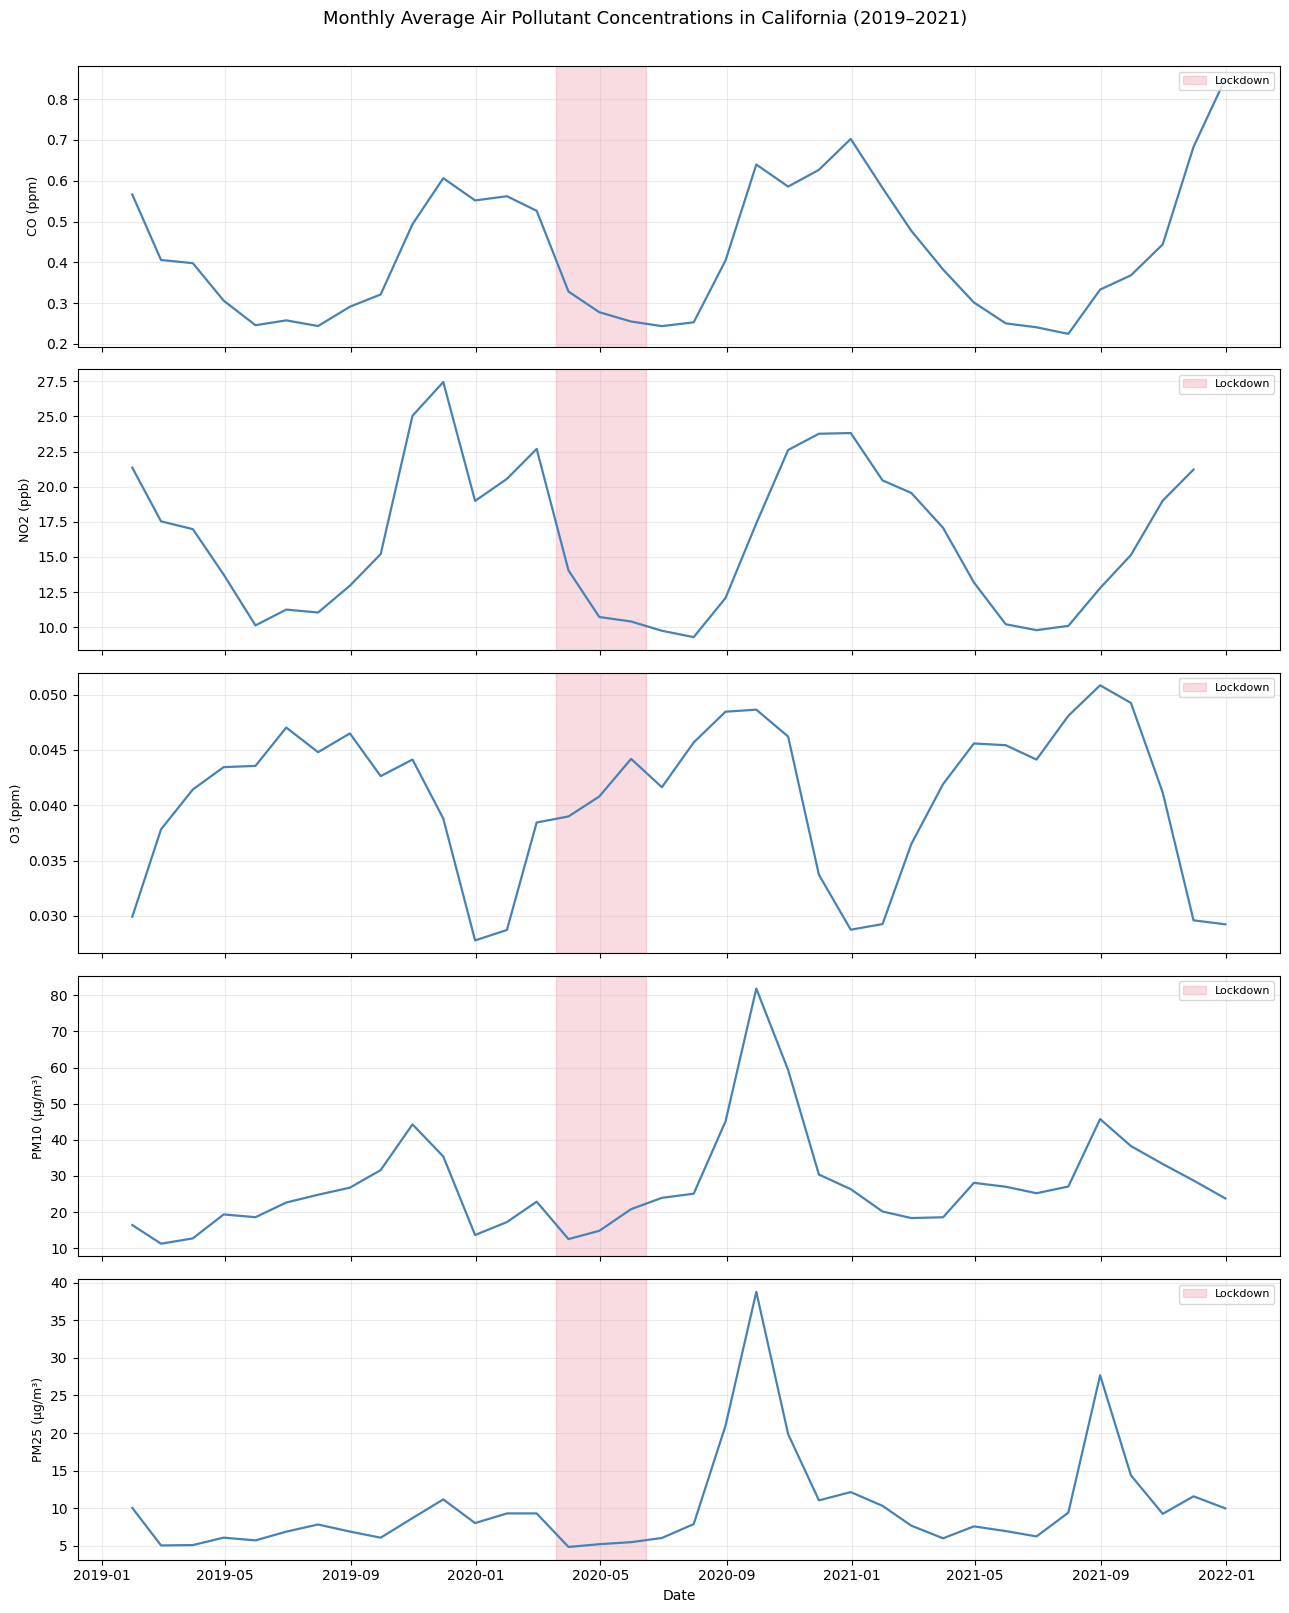

In [ ]:
pollutants = ['co', 'no2', 'o3', 'pm10', 'pm25']
units = {'co': 'ppm', 'no2': 'ppb', 'o3': 'ppm', 'pm10': 'μg/m³', 'pm25': 'μg/m³'}

#daily average across all counties first, then resample to monthly for a cleaner trend line
daily_avg   = aq_covid.groupby('Date')[pollutants].mean()
monthly_avg = daily_avg.resample('M').mean()

fig, axes = plt.subplots(5, 1, figsize=(13, 16), sharex=True)

for ax, col in zip(axes, pollutants):
    ax.plot(monthly_avg.index, monthly_avg[col], color='steelblue', linewidth=1.6)
    ax.axvspan(lockdown_start, lockdown_end, alpha=0.15, color='crimson', label='Lockdown')
    ax.set_ylabel(f'{col.upper()} ({units[col]})', fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Date')
fig.suptitle('Monthly Average Air Pollutant Concentrations in California (2019–2021)',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

### 5.2 Year-over-year comparison

Monthly comparison to identify exactly where 2020 diverged from the 2019 baseline.

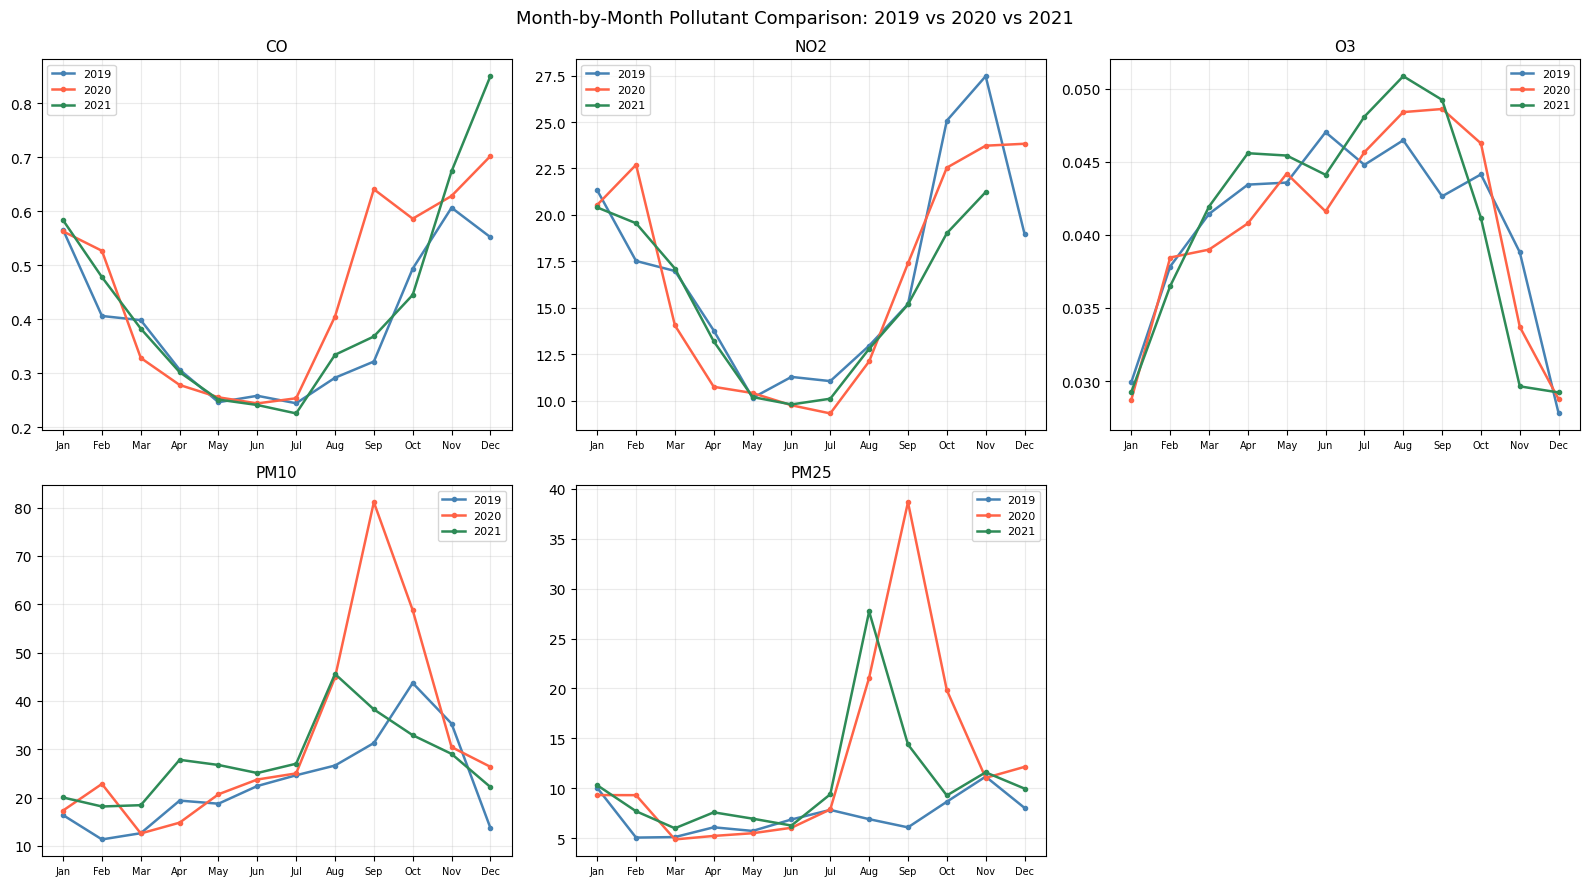

In [100]:
monthly_yr = aq_covid.groupby(['year', 'month'])[pollutants].mean().reset_index()

colors_yr    = {2019: 'steelblue', 2020: 'tomato', 2021: 'seagreen'}
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    for yr in [2019, 2020, 2021]:
        sub = monthly_yr[monthly_yr['year'] == yr]
        axes[i].plot(sub['month'], sub[col], label=str(yr),
                     color=colors_yr[yr], linewidth=1.8, marker='o', markersize=3)
    axes[i].set_title(col.upper(), fontsize=11)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(month_labels, fontsize=7)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.25)

axes[5].set_visible(False)
fig.suptitle('Month-by-Month Pollutant Comparison: 2019 vs 2020 vs 2021', fontsize=13)
plt.tight_layout()
plt.show()

### 5.3 Which counties saw the biggest reduction?

Comparing each county's average air quality levels (all pullutants) during the lockdown window (Mar 19 – Jun 15, 2020) against the exact same window in 2019. This isolates the change that's actually attributable to reduced activity rather than seasonal variation.

In [ ]:
#first, creating separate dataframes (baseline vs. lockdown air quality data)
lockdown_2020 = aq_covid[(aq_covid['Date'] >= lockdown_start) & (aq_covid['Date'] <= lockdown_end)]
baseline_2019 = aq_covid[(aq_covid['Date'] >= '2019-03-19') & (aq_covid['Date'] <= '2019-06-15')]

#calculating average air pollutant value per county
lock_avg = lockdown_2020.groupby('county')[pollutants].mean()
base_avg = baseline_2019.groupby('county')[pollutants].mean()

#calculating change percentage 
pct_change = ((lock_avg - base_avg) / base_avg * 100).round(1)

#calculating average change percentage across all pollutants per county
pct_change['avg_change'] = pct_change[pollutants].mean(axis=1)
pct_change = pct_change.sort_values('avg_change')

pct_change.head(10)

,co,no2,o3,pm10,pm25,avg_change
county,,,,,,
Trinity,NaN,NaN,NaN,NaN,-37.7,-37.700000
Mono,NaN,NaN,NaN,-41.7,-12.6,-27.150000
Mariposa,NaN,NaN,-5.8,-31.7,-43.9,-27.133333
Mendocino,NaN,NaN,NaN,-26.6,NaN,-26.600000
Santa Cruz,NaN,NaN,-9.1,NaN,-41.0,-25.050000
Butte,-6.5,-34.6,-9.5,-21.9,-28.6,-20.220000
San Mateo,-16.9,-28.0,-5.5,NaN,-27.3,-19.425000
Monterey,-46.0,-7.5,-9.8,-22.3,-9.8,-19.080000
Santa Clara,-22.8,-22.1,-5.0,-20.5,-20.5,-18.180000


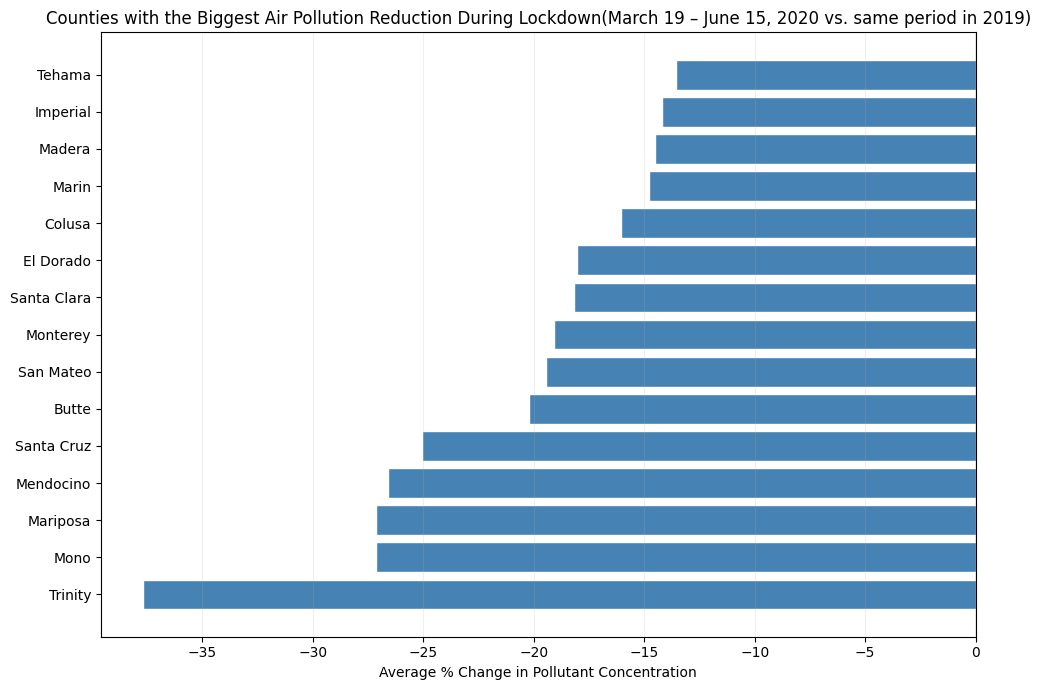

In [ ]:
#plotting the results above
top15 = pct_change.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['steelblue' if x < 0 else 'tomato' for x in top15['avg_change']]
ax.barh(top15.index, top15['avg_change'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Average % Change in Pollutant Concentration')
ax.set_title(
    'Counties with the Biggest Air Pollution Reduction During Lockdown'
    '(March 19 – June 15, 2020 vs. same period in 2019)'
)
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
#confirming county with the biggest overall average reduction across all pollutants
top_county = pct_change['avg_change'].idxmin()
top_value  = pct_change['avg_change'].min()
print(f'County with the biggest overall reduction: {top_county} ({top_value:.1f}% avg across all pollutants)')

County with the biggest overall reduction: Trinity (-37.7% avg across all pollutants)


### 5.4 Which pollutant dropped the most in Trinity?

Average % change per pollutant during lockdown:
no2    -13.415152
pm25   -11.604082
pm10    -7.092857
o3      -6.160417
co      -5.988000
dtype: float64


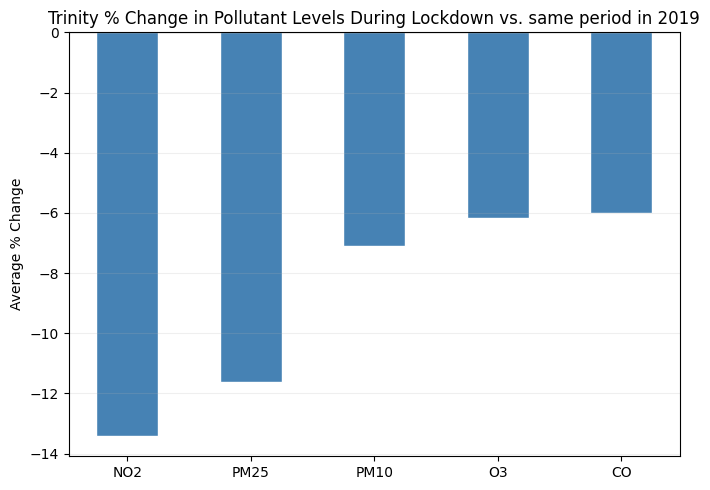

In [113]:
Trinity_pct = pct_change[pollutants].mean().sort_values()
print('Average % change per pollutant during lockdown:')
print(Trinity_pct)

fig, ax = plt.subplots(figsize=(7, 5))
bar_c = ['steelblue' if x < 0 else 'tomato' for x in Trinity_pct]
ax.bar(Trinity_pct.index.str.upper(), Trinity_pct.values,
       color=bar_c, edgecolor='white', width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Average % Change')
ax.set_title('Trinity % Change in Pollutant Levels During Lockdown vs. same period in 2019')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

## 6. Discussion

   Trinity is one of California's least populated counties, with a total population of 16,112 ranking 54th most popultaed county in CA. In terms of land size, Trinity covers a total area of 3,208 square miles, of which 3,179 square miles is land and 28 square miles is water, according to the U.S. Census Bureau reports (2). While Trinity is physically sizeable, it's nearly empty with only 5 people per square mile (one of the emptiest counties in the state), compared to California's overall figure of roughly 250. Thus it's not entirely surprising to see that the least populated counties see a significant drop in air pollution.

   Compared to Humbold, a county of similar size but denser with 37.1 people per square mile (see Limitations):

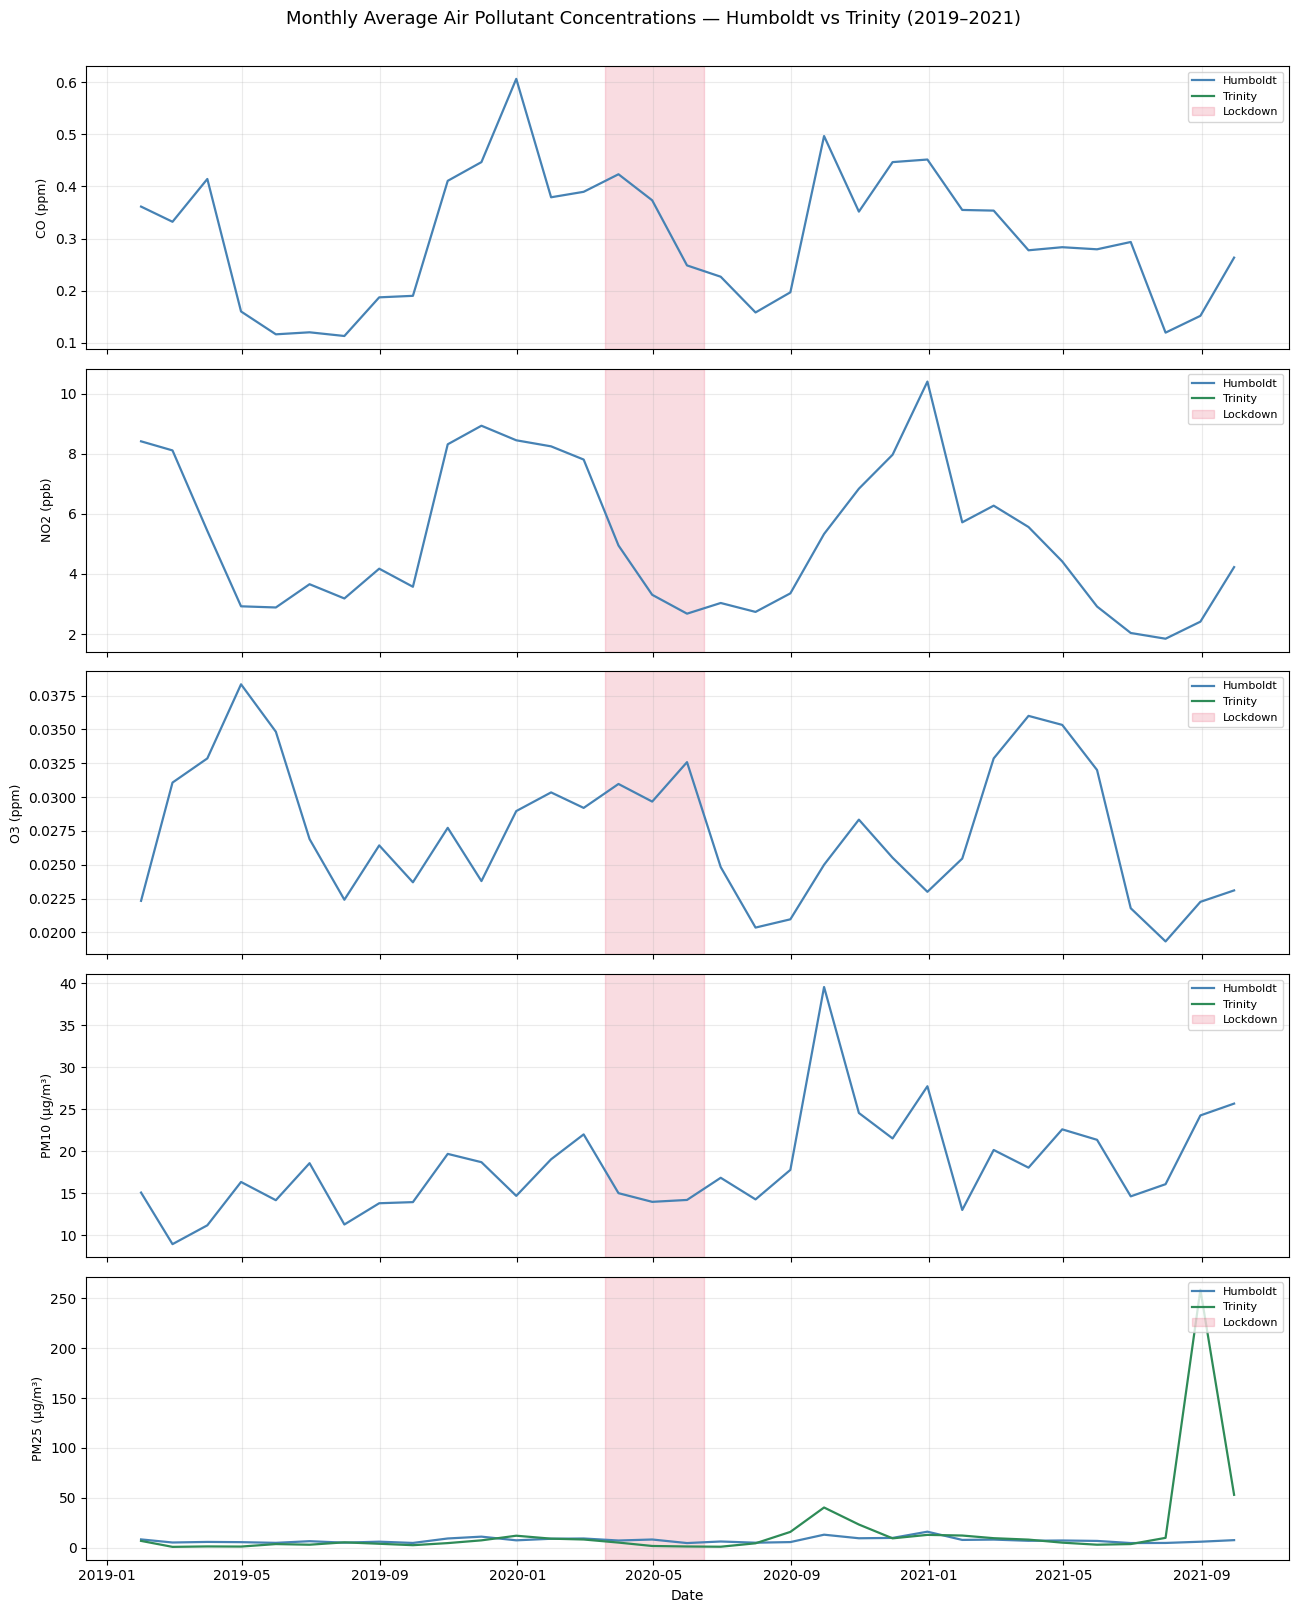

In [118]:
humboldt_trinity = aq_covid[aq_covid['county'].isin(['Humboldt', 'Trinity'])]

daily_avg_ht   = humboldt_trinity.groupby(['Date', 'county'])[pollutants].mean()
monthly_avg_ht = daily_avg_ht.groupby(['county', pd.Grouper(level='Date', freq='M')]).mean()

fig, axes = plt.subplots(5, 1, figsize=(13, 16), sharex=True)

colors_county = {'Humboldt': 'steelblue', 'Trinity': 'seagreen'}

for ax, col in zip(axes, pollutants):
    for county in ['Humboldt', 'Trinity']:
        county_data = monthly_avg_ht.loc[county][col]
        ax.plot(county_data.index, county_data.values,
                label=county, color=colors_county[county], linewidth=1.6)
    ax.axvspan(lockdown_start, lockdown_end, alpha=0.15, color='crimson', label='Lockdown')
    ax.set_ylabel(f'{col.upper()} ({units[col]})', fontsize=9)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Date')
fig.suptitle('Monthly Average Air Pollutant Concentrations — Humboldt vs Trinity (2019–2021)',
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
#overall annual levels in Trinity
print('Trinity annual averages. Did things go back to normal in 2021?')
print(aq_covid.groupby('year')[pollutants].mean().round(3))

Trinity annual averages. Did things go back to normal in 2021?
         co     no2     o3    pm10    pm25
year                                      
2019  0.390  16.799  0.041  23.021   7.314
2020  0.449  16.374  0.040  31.653  12.608
2021  0.373  14.820  0.041  27.652  10.609


Trinity's 2020 air pollutant levels surpass that of 2019 and 2021, specifically PM25 and PM10 levels, despite lockdown. PM10 and PM2.5 levels spiked to 42.934 and 17.526 post-lockdown, respectively. This significant increrase is unlikely due to just human activity returning to normal and more likely linked to the record-breaking California wildfire season in late 2020, given that Trinity is most;y wildreness. 

Compared to Humboldt, levels have returned to normal except for PM 10 and PM2.5; the increase in 2020 had continued in 2021. Given that Humboldt borders Trinity to the west, the geography makes the spillover of smoke from the wild fires in Trinity inevitable. 

In [108]:
humboldt = aq_covid[aq_covid['county'] == 'Humboldt']
print(humboldt.groupby('year')[pollutants].mean().round(3))

         co    no2     o3    pm10   pm25
year                                    
2019  0.286  5.724  0.028  14.707  6.788
2020  0.344  5.567  0.027  20.485  8.755
2021  0.263  3.789  0.028  20.028  6.683


## 7. Limitations
PM25 was consistently recorded in Trinity in comparison to other counties; this might have skewed the results. Suggestion for reproducing this analysis is to set a threshold for which counties are to be included (e.g. a minimum of 3 or 4 or 5 air pollutant recorded.)